# Causal Inference from Observational Data

Estimate the effect of job-training participation on post-treatment earnings using observational data.

**Tools:** DoWhy, propensity scores, inverse probability weighting, scikit-learn

**Design goal:** CPU-friendly, small-data, reproducible, and interview-ready.

## 1. Causal Question

The central question is:

> What would the average post-treatment earnings have been if people who received job training had, counterfactually, not received it?

We cannot observe both outcomes for the same person. This is the fundamental causal inference problem.

Because the data are observational, we must adjust for observed pre-treatment variables and clearly state the assumptions behind the estimate.

In [5]:
from pathlib import Path
import requests
import pandas as pd
import numpy as np

DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "causal_inference_data.csv"

CONTROL_URL = "https://www.nber.org/~rdehejia/data/nswre74_control.txt"
TREATED_URL = "https://www.nber.org/~rdehejia/data/nswre74_treated.txt"

columns = [
    "treat",
    "age",
    "educ",
    "black",
    "hisp",
    "married",
    "nodegr",
    "re74",
    "re75",
    "re78",
]

def download_text(url):
    response = requests.get(
        url,
        timeout=30,
        headers={"User-Agent": "Mozilla/5.0"}
    )
    response.raise_for_status()
    return response.text

# Download the two parts of the Lalonde dataset
control_text = download_text(CONTROL_URL)
treated_text = download_text(TREATED_URL)

# Read the whitespace-separated files
from io import StringIO

control = pd.read_csv(
    StringIO(control_text),
    sep=r"\s+",
    header=None,
    names=columns
)

treated = pd.read_csv(
    StringIO(treated_text),
    sep=r"\s+",
    header=None,
    names=columns
)

# Combine treated and control observations
df = pd.concat(
    [control, treated],
    ignore_index=True
)

# Add unemployment indicators used in the causal analysis
df["u74"] = np.where(df["re74"] == 0, 1.0, 0.0)
df["u75"] = np.where(df["re75"] == 0, 1.0, 0.0)

# Save a local copy so the data does not need to be downloaded again
df.to_csv(DATA_PATH, index=False)

print(f"Dataset saved to: {DATA_PATH}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

display(df.head())

Dataset saved to: ..\data\causal_inference_data.csv
Rows: 445
Columns: 12


,treat,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75
0,0.0,23.0,10.0,1.0,0.0,0.0,1.0,0.0,0.0,0.00,1.0,1.0
1,0.0,26.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,12383.68,1.0,1.0
2,0.0,22.0,9.0,1.0,0.0,0.0,1.0,0.0,0.0,0.00,1.0,1.0
3,0.0,18.0,9.0,1.0,0.0,0.0,1.0,0.0,0.0,10740.08,1.0,1.0
4,0.0,45.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,11796.47,1.0,1.0


## 2. Inspect the Data

The Lalonde data contain a treatment indicator and an earnings outcome along with observed characteristics such as age, education, race, marital status, prior earnings, and prior employment indicators.

In [6]:
print(df.info())
display(df.describe(include="all").T)
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   treat    445 non-null    float64
 1   age      445 non-null    float64
 2   educ     445 non-null    float64
 3   black    445 non-null    float64
 4   hisp     445 non-null    float64
 5   married  445 non-null    float64
 6   nodegr   445 non-null    float64
 7   re74     445 non-null    float64
 8   re75     445 non-null    float64
 9   re78     445 non-null    float64
 10  u74      445 non-null    float64
 11  u75      445 non-null    float64
dtypes: float64(12)
memory usage: 41.8 KB
None


,count,mean,std,min,25%,50%,75%,max
treat,445.0,0.415730,0.493402,0.0,0.0,0.000,1.0000,1.00
age,445.0,25.370787,7.100282,17.0,20.0,24.000,28.0000,55.00
educ,445.0,10.195506,1.792119,3.0,9.0,10.000,11.0000,16.00
black,445.0,0.833708,0.372762,0.0,1.0,1.000,1.0000,1.00
hisp,445.0,0.087640,0.283090,0.0,0.0,0.000,0.0000,1.00
married,445.0,0.168539,0.374766,0.0,0.0,0.000,0.0000,1.00
nodegr,445.0,0.782022,0.413337,0.0,1.0,1.000,1.0000,1.00
re74,445.0,2102.265311,5363.582400,0.0,0.0,0.000,824.3889,39570.68
re75,445.0,1377.138368,3150.960771,0.0,0.0,0.000,1220.8360,25142.24
re78,445.0,5300.763699,6631.491695,0.0,0.0,3701.812,8124.7150,60307.93



Missing values:


treat      0
age        0
educ       0
black      0
hisp       0
married    0
nodegr     0
re74       0
re75       0
re78       0
u74        0
u75        0
dtype: int64

In [7]:
# Common DoWhy Lalonde column names are treatment='treat' and outcome='re78'.
treatment = "treat"
outcome = "re78"

print(df[treatment].value_counts())
display(df.groupby(treatment)[outcome].agg(["count", "mean", "median", "std"]))

treat
0.0    260
1.0    185
Name: count, dtype: int64


,count,mean,median,std
treat,,,,
0.0,260,4554.801126,3138.7955,5483.835991
1.0,185,6349.143530,4232.3090,7867.402218


## 3. A Naive Difference in Means

A useful baseline is the observed difference in average outcomes between treated and untreated people. It is **not automatically a causal effect**, because treatment assignment may differ systematically between groups.

In [8]:
naive_effect = df.loc[df[treatment] == 1, outcome].mean() - df.loc[df[treatment] == 0, outcome].mean()
print(f"Naive difference in mean earnings: ${naive_effect:,.2f}")

Naive difference in mean earnings: $1,794.34


## 4. Propensity Scores

The propensity score is the estimated probability of receiving treatment conditional on observed pre-treatment characteristics.

We use logistic regression as a transparent, lightweight estimator. In an interview, this is easy to explain and fast enough for a CPU-only workflow.

In [9]:
candidate_covariates = [
    c for c in ["age", "educ", "black", "hispan", "married", "nodegr", "re74", "re75", "u74", "u75"]
    if c in df.columns
]

X = df[candidate_covariates].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True))
y = df[treatment].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
propensity_model = LogisticRegression(max_iter=2000, random_state=42)
propensity_model.fit(X_scaled, y)
df["propensity_score"] = propensity_model.predict_proba(X_scaled)[:, 1]

display(df[[treatment, "propensity_score"]].head())
print(df["propensity_score"].describe())

,treat,propensity_score
0,0.0,0.338745
1,0.0,0.481943
2,0.0,0.352351
3,0.0,0.344047
4,0.0,0.368893


count    445.000000
mean       0.415741
std        0.095033
min        0.155590
25%        0.341665
50%        0.388257
75%        0.484231
max        0.671233
Name: propensity_score, dtype: float64


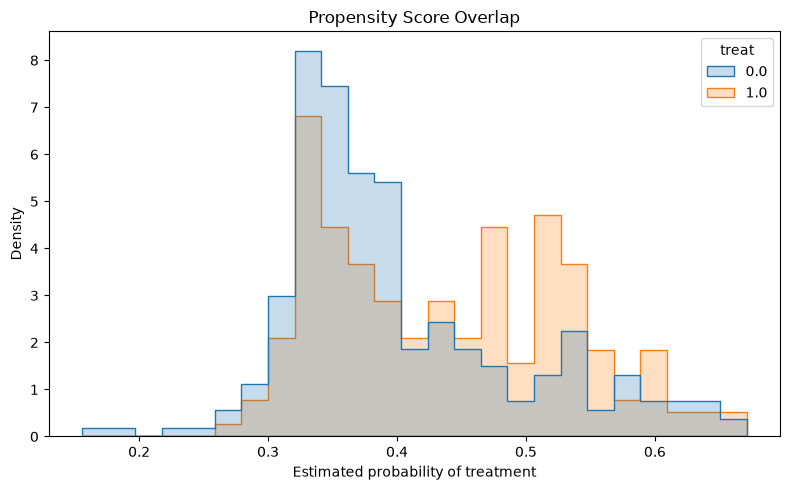

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="propensity_score", hue=treatment, bins=25, element="step", stat="density", common_norm=False)
plt.title("Propensity Score Overlap")
plt.xlabel("Estimated probability of treatment")
plt.tight_layout()
plt.show()

### Positivity / overlap

Causal weighting becomes unstable when observations have propensity scores extremely close to 0 or 1. We inspect the overlap before interpreting the estimate.

In [11]:
print("Propensity score range:", round(df["propensity_score"].min(), 4), "to", round(df["propensity_score"].max(), 4))
print("Scores below 0.05:", int((df["propensity_score"] < 0.05).sum()))
print("Scores above 0.95:", int((df["propensity_score"] > 0.95).sum()))

Propensity score range: 0.1556 to 0.6712
Scores below 0.05: 0
Scores above 0.95: 0


## 5. Inverse Probability Weighting (IPW)

IPW creates a weighted pseudo-population in which treatment assignment is more balanced with respect to the observed covariates.

For a binary treatment, the unstabilized ATE estimator is based on weights:

$$w_i = \frac{T_i}{e(X_i)} + \frac{1-T_i}{1-e(X_i)}$$

where $e(X_i)$ is the propensity score.

In [14]:
eps = 1e-3
p = df["propensity_score"].clip(eps, 1 - eps)
t = df[treatment].astype(int)
y_outcome = df[outcome].astype(float)

treated_weight = t / p
control_weight = (1 - t) / (1 - p)

mu1 = np.sum(treated_weight * y_outcome) / np.sum(treated_weight)
mu0 = np.sum(control_weight * y_outcome) / np.sum(control_weight)
ipw_ate = mu1 - mu0
            
print(f"IPW estimated ATE: ${ipw_ate:,.2f}")

IPW estimated ATE: $1,626.11


## 6. DoWhy Causal Model

DoWhy makes the causal assumptions explicit. The DAG below says that observed pre-treatment characteristics influence both treatment and earnings. We then identify the causal effect using backdoor adjustment and estimate it from the data.

In [15]:
confounders = [c for c in candidate_covariates if c in df.columns]
graph = "digraph { " + "; ".join([f'{c} -> {treatment}; {c} -> {outcome}' for c in confounders]) + f" {treatment} -> {outcome}; }}"

causal_model = CausalModel(
    data=df,
    treatment=treatment,
    outcome=outcome,
    graph=graph,
    missing_nodes_as_confounders=False,
)

identified_estimand = causal_model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                             
────────(E[re78|black,age,educ,re75,u74,married,re74,nodegr,u75])
d[treat]                                                         
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,black,age,educ,re75,u74,married,re74,nodegr,u75,U) = P(re78|treat,black,age,educ,re75,u74,married,re74,nodegr,u75)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
   d                                                             
────────(E[re78|black,age,educ,re75,u74,married,re74,nodegr,u75])
d[treat]                                                         
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,black,ag

## 7. Estimate the Treatment Effect

For a compact portfolio project, we use DoWhy's backdoor linear-regression estimator as a transparent second causal estimate. The IPW estimate above provides an independent comparison.

In [16]:
estimate = causal_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True,
)

print(f"DoWhy ATE estimate: ${estimate.value:,.2f}")
print("\nInterpretation:")
print("The estimate represents the model-based average change in post-treatment earnings associated with the treatment, under the stated causal assumptions.")

DoWhy ATE estimate: $1,656.98

Interpretation:
The estimate represents the model-based average change in post-treatment earnings associated with the treatment, under the stated causal assumptions.


## 8. Refutation / Robustness Check

A causal estimate should not be accepted just because a model produced a number. DoWhy can perform refutation tests that deliberately challenge the estimate.

In [17]:
try:
    placebo = causal_model.refute_estimate(
        identified_estimand,
        estimate,
        method_name="placebo_treatment_refuter",
        placebo_type="permute",
        num_simulations=20,
    )
    print(placebo)
except Exception as exc:
    print("Refutation test could not be completed in this environment:", exc)
    print("The main causal estimate is still available above; see the README for assumptions and limitations.")

Refute: Use a Placebo Treatment
Estimated effect:1656.984009440519
New effect:117.41704249731215
p value:0.42187115270107745



## 9. Results Summary

The key interview point is not a single number. It is the reasoning chain: observational data → causal question → DAG/assumptions → propensity score → identification → estimation → robustness check → limitations.

In [18]:
results = pd.DataFrame({
    "Method": ["Naive difference", "IPW", "DoWhy backdoor regression"],
    "Estimated ATE": [naive_effect, ipw_ate, estimate.value],
})
results["Estimated ATE"] = results["Estimated ATE"].round(2)
display(results)

print("\nCausal interpretation should be made only after considering overlap, confounding assumptions, model specification, and refutation results.")

,Method,Estimated ATE
0,Naive difference,1794.34
1,IPW,1626.11
2,DoWhy backdoor regression,1656.98



Causal interpretation should be made only after considering overlap, confounding assumptions, model specification, and refutation results.


## 10. Interview Talking Points

- **Why not just compare means?** Treatment is not randomly assigned, so observed differences can mix treatment effects with selection bias.
- **Why propensity scores?** They summarize observed treatment-selection patterns and can be used to construct a more balanced pseudo-population.
- **Why DoWhy?** It makes the causal graph and identification assumptions explicit instead of hiding them behind a prediction model.
- **What is the biggest limitation?** Unmeasured confounding can still bias the estimate.
- **Why is this CPU-friendly?** The dataset is small and the estimators are classical statistical/causal methods rather than large neural networks.

## 11. Conclusion

This notebook demonstrates a complete causal inference workflow on observational data while keeping the implementation small enough for a personal laptop. The Django app in `webapp/` turns the analysis into a simple interactive portfolio demonstration.